In [546]:
import emcee
import numpy as np
import matplotlib.pyplot as pt
import matplotlib.gridspec as gridspec

In [547]:
def logK1(d):
    d/=0.5
    return -d*d
def logK2(d):
    d/=0.3
    return -d*d

def TkVector(lk2):
    max = np.max(lk2)
    exper = np.exp(lk2 - max)
    return exper/np.sum(exper)


In [548]:
def SpoofMAP(Ndmax,Nemax,preddim):
    global deppos, exppos
    deppos = []
    exppos = []
    ## positions
    for i in range(Ndmax):
        x = np.random.uniform(0,2)
        y = np.random.uniform(0,2)
        deppos.append([x,y])
    for j in range(Nemax):
        if j < len(deppos):
            exppos.append(deppos[j] + np.random.normal(0,0.1,(2,)))
        else:
            x = np.random.uniform(0,2)
            y = np.random.uniform(0,2)
            exppos.append([x,y])

    ## phis
    phidim = int(preddim*(preddim+1)/2)
    global phis
    phis = []
    for i in range(Ndmax):
        phi = np.random.uniform(0.2,0.8,(phidim,)) + np.random.normal(0,0.5,(phidim,))
        phis.append(phi)
    global mus,sigmas
    mus = []
    sigmas = []
    for i in range(Nemax):
        mus.append(np.random.uniform(1,3))
        sigmas.append(np.random.lognormal(-1,1))

In [549]:
class Model:
    def __init__(self,dim,nd,ne):
        self.Nd = nd
        self.Ne = ne
        self.Dim = dim
        self.DepartmentPos = np.zeros((nd,self.Dim))
        self.ForceEuclid = False
        self.Phidim = int(dim*(dim+1)/2)
        self.Phis = np.zeros((nd,self.Phidim))
        self.Gk = []

        self.ExpertPos = np.zeros((ne,self.Dim))

        self.ExpertMu = [0]*ne
        self.ExpertSigma = [1]*ne

        self.TotalDim = (ne+nd)*dim + nd * self.Phidim + 2*ne
        self.SetCovariateBounds(0,1)
        self.SetPriorStrengths()
    def MakeGk(self):
        self.Gk = []
        for k in range(self.Nd):
            L = np.zeros((self.Dim,self.Dim))
            q = 0
            for i in range(self.Dim):
                L[i,i] = np.exp(self.Phis[k][q])
                q+=1
                for j in range(i):
                    L[i,j] = self.Phis[k][q]
                    q+=1
            G = L @ L.T
            G /= np.linalg.det(G) *np.random.uniform(0.5,1.5)
            if self.ForceEuclid:
                G = np.eye(self.Dim)
            self.Gk.append(G)
    def MakeTik(self):
        self.T = np.zeros((self.Nd,self.Ne))

        for i in range(self.Ne):
            x = self.ExpertPos[i]
            
            lk2s = np.zeros((self.Nd))
   
            for k in range(self.Nd):
                diff =   (x - self.DepartmentPos[k])
                dist = diff.T @ self.Gk[k] @diff
                lk2s[k] = logK2(dist)
            self.T[:,i] = TkVector(lk2s)

    def MakeWik(self,x):
        self.Wik = np.zeros((self.Nd,self.Ne))

        for k in range(self.Nd):
            container = np.log(1e-100+ self.T[k,:])
           
            for i in range(self.Ne):
                diff = (x - self.ExpertPos[i])
                dist = diff.T @ self.Gk[k] @diff
                container[i] += logK1(dist)
            self.Wik[k,:] =TkVector(container)
    def MakeInternals(self):
        self.MakeGk()
        self.MakeTik()
    def Complexity(self):
        return self.TotalDim
    def SetCovariateBounds(self,lowerBounds,upperBounds):
        if isinstance(lowerBounds,(int,float)):
            lowerBounds = [lowerBounds]*self.Dim
        if isinstance(upperBounds,(int,float)):
            upperBounds = [upperBounds]*self.Dim
        self.Lower = lowerBounds
        self.Upper = upperBounds

    def SetPriorStrengths(self):
        self.PhiSigma = 1
        
    def PriorCost(self):
        gamma = 0
        
        
        phis = 0
        for i in range(self.Nd):
            ##out of bounds
            for j in range(self.Dim):
                x = self.DepartmentPos[i][j]
                if x < self.Lower[j] or x > self.Upper[j]:
                    return -np.isnan
                
            for j in range(self.Phidim):
                d = self.Phis[i][j]/self.PhiSigma
                phis -= 0.5 * (d)**2

        mus = 0
        for i in range(self.Ne):
            for j in range(self.Dim):
                x = self.ExpertPos[i][j]
                if x < self.Lower[j] or x > self.Upper[j]:
                    return -np.isnan
        complexity = -gamma * np.log(self.Nd * self.Ne)

        return complexity + phis
    def AnalyticalPriorDraw(self):
        for i in range(self.Nd):
            for j in range(self.Dim):
                self.DepartmentPos[i,j] = np.random.uniform(self.Lower[j],self.Upper[j])
            for j in range(self.Phidim):
                self.Phis[i,j] = np.random.normal(0,self.PhiSigma)
        for i in range(self.Ne):
            for j in range(self.Dim):
                self.ExpertPos[i,j] = np.random.uniform(self.Lower[j],self.Upper[j])
            self.ExpertMu[i] = np.random.uniform(-6,6)
            self.ExpertSigma[i] = np.random.uniform(0.3,2)
        self.MakeInternals()
   
    def SetSpoofed(self):
        for i in range(self.Nd):
            for j in range(self.Dim):
                self.DepartmentPos[i,j] = deppos[i][j]
            for j in range(self.Phidim):
                self.Phis[i,j] = phis[i][j]
        for i in range(self.Ne):
            for j in range(self.Dim):
                self.ExpertPos[i,j] =exppos[i][j]# np.random.uniform(self.Lower[j],self.Upper[j])
            self.ExpertMu[i] = mus[i] #np.random.uniform(-1,6)
            self.ExpertSigma[i] = sigmas[i] #np.random.uniform(0.1,2)
        self.MakeInternals()

    def OscillateSpoofed(self):
        min = 0.01
        max = 0.03
        for i in range(self.Nd):
            for j in range(self.Dim):
                self.DepartmentPos[i,j] = deppos[i][j] + np.random.normal(0,np.random.uniform(min,max))
            for j in range(self.Phidim):
                self.Phis[i,j] = phis[i][j] + np.random.normal(0,np.random.uniform(min,max))
        for i in range(self.Ne):
            for j in range(self.Dim):
                self.ExpertPos[i,j] =exppos[i][j]+ np.random.normal(0,np.random.uniform(min,max))
            self.ExpertMu[i] = mus[i]+ np.random.normal(0,np.random.uniform(min,max))
            self.ExpertSigma[i] = sigmas[i] + np.random.normal(0,np.random.uniform(min,max))
        self.MakeInternals()
    def Predict(self,x,grid):
        out = np.zeros(grid.size)
        
        lk2s = np.zeros((self.Nd))
   
        for k in range(self.Nd):
            diff =   (x - self.DepartmentPos[k])
            dist = diff.T @ self.Gk[k] @diff
            lk2s[k] = logK2(dist)
   

        Tkx = TkVector(lk2s)
        
        self.MakeWik(x)
        for i in range(self.Ne):
            prod =0
            for k in range(self.Nd):
                prod  += Tkx[k] * self.Wik[k,i]
            d = (grid - self.ExpertMu[i])/self.ExpertSigma[i]
            pdf = np.exp(-0.5*d*d)/(np.sqrt(2*np.pi) * self.ExpertSigma[i])
            # lg = np.log(grid)
            # d = (lg - self.ExpertMu[i])/self.ExpertSigma[i]
            # pdf = np.exp(-0.5*d*d - lg)/(np.sqrt(2*np.pi) * self.ExpertSigma[i]*grid)
            out += prod * pdf 
        return out
    def PredictComponents(self,x,grid):
        out = np.zeros(grid.size)
        comp = []
        lk2s = np.zeros((self.Nd))
   
        for k in range(self.Nd):
            diff =   (x - self.DepartmentPos[k])
            dist = diff.T @ self.Gk[k] @diff
            lk2s[k] = logK2(dist)
   

        Tkx = TkVector(lk2s)
        
        self.MakeWik(x)
        for i in range(self.Ne):
            prod =0
            for k in range(self.Nd):
                prod  += Tkx[k] * self.Wik[k,i]
            d = (grid - self.ExpertMu[i])/self.ExpertSigma[i]
            pdf = np.exp(-0.5*d*d)/(np.sqrt(2*np.pi) * self.ExpertSigma[i])
            # lg = gridnp.log(grid)
            # d = (lg - self.ExpertMu[i])/self.ExpertSigma[i]
            # pdf = np.exp(-0.5*d*d - lg)/(np.sqrt(2*np.pi*grid) * self.ExpertSigma[i])
            r = prod * pdf
            comp.append(r)
            out += r 
        return out,comp
    def Visualise(self,axs,res=100):
        if self.Dim == 2:
            cmap="viridis"
            axs.set_xlim(self.Lower[0],self.Upper[0])
            axs.set_ylim(self.Lower[1],self.Upper[1])
            
            x = np.linspace(self.Lower[0],self.Upper[0],res)
            y = np.linspace(self.Lower[1],self.Upper[1],res)

            X,Y = np.meshgrid(x,y)
            Z = np.zeros((res,res))
            distances = np.zeros((self.Nd,))
            karr = np.arange(0,self.Nd)
            for i in range(res):
                for j in range(res):
                    pos = np.array([x[i],y[j]])
            
            
                    for k in range(self.Nd):
                        seedPos = self.DepartmentPos[k]
                        seedMetric = self.Gk[k]

                        diff = (seedPos - pos)
                        
                        dist = np.sqrt(diff.T @ seedMetric @ diff)
                        distances[k] = dist
                    exper = logK2(distances)
                    m= np.max(exper)
                    exper = np.exp(exper - m)
                    probs = exper/np.sum(exper)
                    Z[j,i] = np.sum(probs*karr)
            axs.imshow(Z,extent=[self.Lower[0],self.Upper[0],self.Lower[1],self.Upper[1]],origin='lower',cmap=cmap)
            axs.scatter(self.ExpertPos[:,0],self.ExpertPos[:,1],10,'r')
            axs.scatter(self.DepartmentPos[:,0],self.DepartmentPos[:,1],30,'k',marker='*')


def PosteriorPredictive(DepMax,ExpMax,pos,grid,sumres,ndbest,nebest,forceEuclid=False):
    x = grid
    out = np.zeros(x.shape)
    for Nd in range(2,DepMax+1):
        for Ne in range(2,ExpMax+1):
            m = Model(2,Nd,Ne)
            m.ForceEuclid = forceEuclid
            m.SetCovariateBounds([0,0],[2,2])

            for q in range(sumres):
                m.OscillateSpoofed()
                alpha = 0.1
                intDist = 1#np.exp(- alpha*(np.abs(Nd - ndbest) - np.abs(Ne-nebest)))
                out += m.Predict(pos,x) * intDist

    out /= np.trapezoid(out,x)
    return out


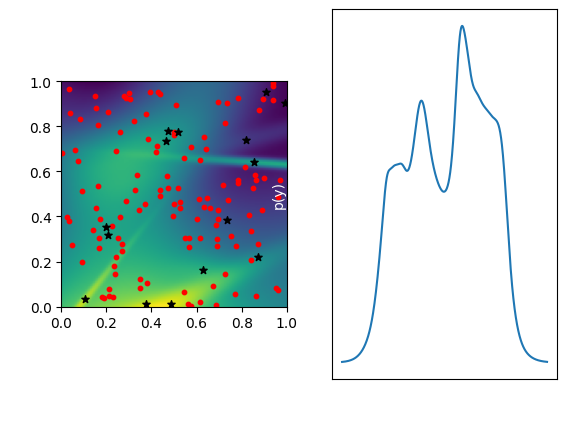

In [550]:
# np.random.seed(3)
m = Model(2,15,125)

m.SetCovariateBounds([0,0],[1,1])
m.AnalyticalPriorDraw()

fig,axs = pt.subplots(1,2)

m.Visualise(axs[0],140)
axs[0].set_xlabel("Covariate 1",color="w")
axs[0].set_ylabel("Covariate 2",color="w")
pt.tick_params(axis='both', colors='white')


grid = np.linspace(-10,10,1000)
y,c = m.PredictComponents([0.5,0.5],grid)
axs[1].set_xlabel("y",color="w")
axs[1].set_ylabel("p(y)",color="w")
axs[1].plot(grid,y)
# axs[1].axis('square')
# pt.savefig("query.pdf",transparent=True,bbox_inches='tight')
pt.show()

In [551]:
from tqdm import tqdm
DepMax = 12
ExpMax = 30
S = 13
queryPoint = [2,1]

x = np.linspace(-3,5,200)
np.random.seed(3)
SpoofMAP(DepMax,ExpMax,2)


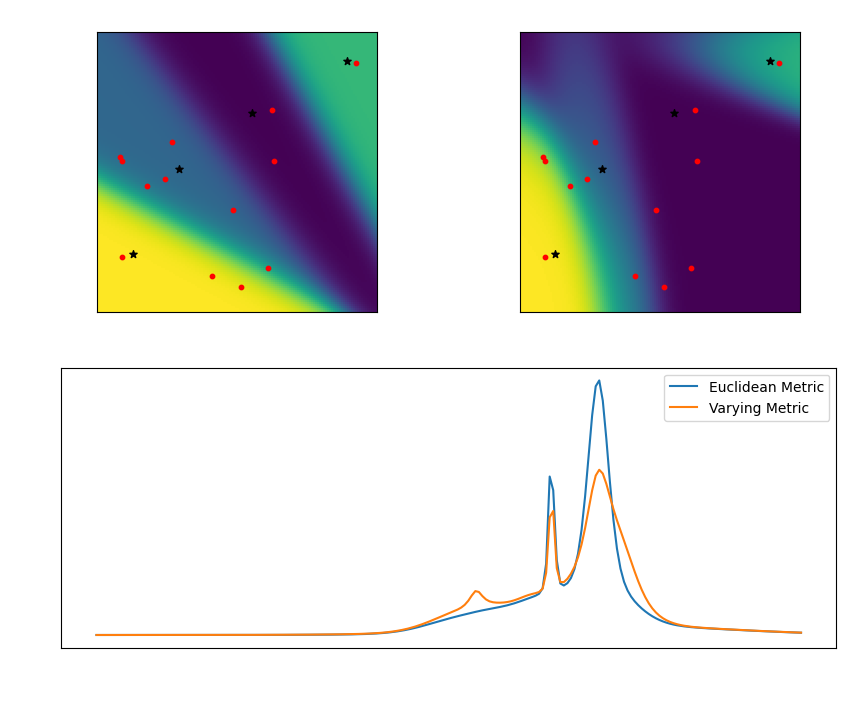

In [556]:

ndbest = 4
nebest = 14

m = Model(2,ndbest,nebest)
m.SetCovariateBounds([0,0],[2,2])

fig = pt.figure(figsize=(10, 8))

# Define a 2x2 grid
gs = gridspec.GridSpec(2, 2)

axs = [fig.add_subplot(gs[0,0]),fig.add_subplot(gs[0,1]),fig.add_subplot(gs[1,0:2])]
for r in [0,1]:
    m.ForceEuclid = bool(1-r)
    m.SetSpoofed()

    m.Visualise(axs[r],140)

    y = m.Predict(queryPoint,x)
    
    yPP = PosteriorPredictive(DepMax,ExpMax,queryPoint,x,S,ndbest,nebest,m.ForceEuclid)
    
    axs[r].set_title("Departments with " + ("Euclidean Metric" if m.ForceEuclid else "Varying Metric"),color="w")
    axs[r].set_xlabel("Covariate 1",color="w")
    axs[r].set_ylabel("Covariate 2",color="w")
    axs[r].tick_params(axis='both', colors='white')
    # axs[0,1].plot(x,y,label="Varying" if m.ForceEuclid else "Constant")
    axs[2].plot(x,yPP,label="Euclidean Metric" if m.ForceEuclid else "Varying Metric")
    axs[2].set_title("Emulated Distribution at (1,1)",color="w")
axs[2].set_xlabel("y",color="w")
axs[2].set_ylabel("p(y)",color="w")

axs[2].tick_params(axis='both', colors='white')
axs[2].legend()

# pt.savefig("Work/Emulator/presentations/images/fde_grid.pdf",transparent=True,bbox_inches='tight')
pt.savefig("Work/Emulator/presentations/images/metric_grids.pdf",transparent=True,bbox_inches='tight')

# grid = np.linspace(-1,5,500)
# yBestFit,c = m.PredictComponents([1,1],grid)
# yBestFit /=np.trapezoid(yBestFit,grid)
# pt.plot(grid,yBestFit)
# # for yc in c:
# #     pt.plot(grid,yc,'--')
pt.show()

